# Libraries

In [1]:
import os
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import seaborn as sns
import joblib
 
from functions_ import *

from UQpy.distributions import Uniform, JointIndependent

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False
})

d:\Documentos\ic_victor\myenv\Lib\site-packages\UQpy\__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Machine learning model for carbonation process

In [23]:
name_best_model = r'D:\Documentos\ic_victor\beam_problem_1\model_NeuralNetwork_MLP_fold_4.pkl'
model           = joblib.load(name_best_model)   
model

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpregressor',
                 MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=2000,
                              random_state=42))])

# Instance of the beam problem

In [19]:
geo = {
        'b_w [m]': 0.20,
        'h [m]': 0.25,
        'l [m]': 6.00,
        'n bars': 4,
        'phi [m]': 0.0125,
        'ratio d/h': 0.84,
        'cover [m]': 0.015
      }

mat= {
        'f_yk [kPa]': 500E3,
        'f_ck [kPa]': 30E3,
        'e_s [kPa]': 200E6,
        'gamma_c': 1.0,
        'gamma_s': 1.0,
        'Type of cement': 3
      }

load = {
          'g_k [kN/m]': 5.0,
          'q_k [kN/m]': 2.0,
          'gamma_g': 1.0,
          'gamma_q': 1.0
       }

expo = {
          'temp [°C]': 20.0,
          'Relative humidity [%]': 65.0,
          'Installation year': 1990,
            'Exposure conditions': 2
       } 

beam_test = Beam(geo, mat, load, expo)

#### Latent variable generation

(array([ 1.,  0.,  0.,  0.,  1.,  0.,  1.,  1.,  2.,  2.,  5.,  4.,  4.,
        10., 22., 21., 31., 29., 39., 49., 39., 53., 65., 69., 60., 49.,
        58., 57., 59., 51., 34., 36., 25., 20., 31., 14., 13., 13.,  6.,
         8.,  5.,  4.,  3.,  3.,  0.,  2.,  0.,  0.,  0.,  1.]),
 array([0.8097517 , 0.81731307, 0.82487443, 0.8324358 , 0.83999717,
        0.84755853, 0.8551199 , 0.86268127, 0.87024263, 0.877804  ,
        0.88536536, 0.89292673, 0.9004881 , 0.90804946, 0.91561083,
        0.9231722 , 0.93073356, 0.93829493, 0.94585629, 0.95341766,
        0.96097903, 0.96854039, 0.97610176, 0.98366312, 0.99122449,
        0.99878586, 1.00634722, 1.01390859, 1.02146996, 1.02903132,
        1.03659269, 1.04415405, 1.05171542, 1.05927679, 1.06683815,
        1.07439952, 1.08196089, 1.08952225, 1.09708362, 1.10464498,
        1.11220635, 1.11976772, 1.12732908, 1.13489045, 1.14245181,
        1.15001318, 1.15757455, 1.16513591, 1.17269728, 1.18025865,
        1.18782001]),
 <BarContainer

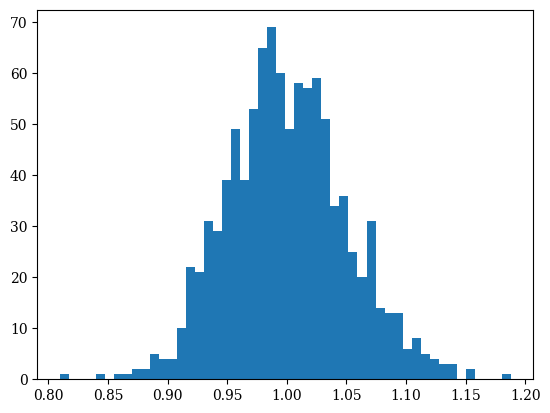

In [20]:
n_latent_samples = 1000
rh_beam = beam_test.latent_variable_generator(n_latent_samples)
plt.hist(rh_beam, bins=50)

#### CO2 percentage in the atmosphere

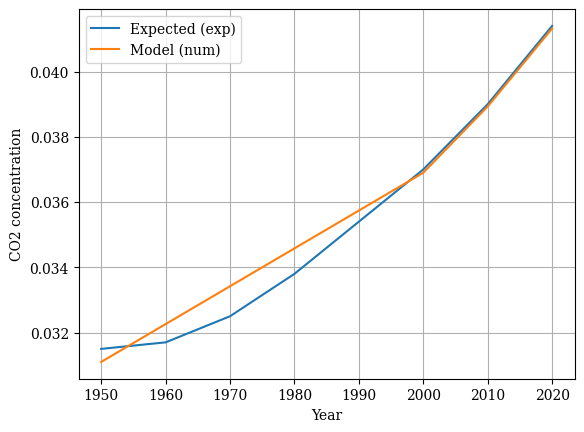

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# intervalo de anos
times = [1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020]

co2_exp_values = [0.0315, 0.0317, 0.0325, 0.0338, 0.0354, 0.0370, 0.0390, 0.0414] # valores experimentais (exemplo)
co2_num_values = []

for j in range(len(times)):
    
    year = times[j]
    
    # modelo numérico (seu código)
    co2_num = beam_test.co2_percentage_year(year)
    co2_num_values.append(co2_num)

# plot
plt.figure()
plt.plot(times, co2_exp_values, label='Expected (exp)')
plt.plot(times, co2_num_values, label='Model (num)')
plt.xlabel('Year')
plt.ylabel('CO2 concentration')
plt.legend()
plt.grid()

plt.show()

#### Carbonation profile and specific pick time

In [13]:
profile = beam_test.carbonation_profile(model=model, lifetime=100)
profile

,calendar year,t (years),CO2 (%),carbonation depth (mm)
0,1990,0,0.035740,0.195415
1,1991,1,0.035856,1.703449
2,1992,2,0.035972,3.216830
3,1993,3,0.036088,4.730212
4,1994,4,0.036204,5.763453
...,...,...,...,...
96,2086,96,0.066123,29.465820
97,2087,97,0.066619,29.612826
98,2088,98,0.067119,29.761172
99,2089,99,0.067623,29.916254


In [39]:
depth_at_time = beam_test.carbonation_depth_at_time(profile=profile, t_query=2010)
depth_at_time

13.58528965923041

#### Test whole pipeline

##### Final test: State Limit Function generator

In [21]:
n_samples        = 1000
n_latent_samples = 1000
cover  = Uniform(loc=0.02, scale=0.02)
fck    = Uniform(loc=25E3, scale=50E3-25E3)
rh    = Uniform(loc=20, scale=60)
joint  = JointIndependent(marginals=[cover, fck, rh])
x      = joint.rvs(n_samples)
x

array([[3.99988208e-02, 2.99895985e+04, 7.97131988e+01],
       [2.89299732e-02, 4.20357387e+04, 6.87236117e+01],
       [2.18716831e-02, 2.68150747e+04, 4.28298012e+01],
       ...,
       [3.37171009e-02, 4.72852225e+04, 4.84121786e+01],
       [3.53782107e-02, 4.18104058e+04, 5.74180859e+01],
       [2.35593309e-02, 3.88762569e+04, 3.64927788e+01]])

In [5]:
times = [0., 10., 20., 30., 40., 50., 60., 70., 80., 90., 100.]
for time in times:
    df = state_limit_function_time(x,["cover", "fck", "rh"], carb_model=model,time_step=time, n_latent_samples=n_latent_samples)
    joblib.dump(df, f"df_time_{time}.pkl")
    

<function matplotlib.pyplot.show(close=None, block=None)>

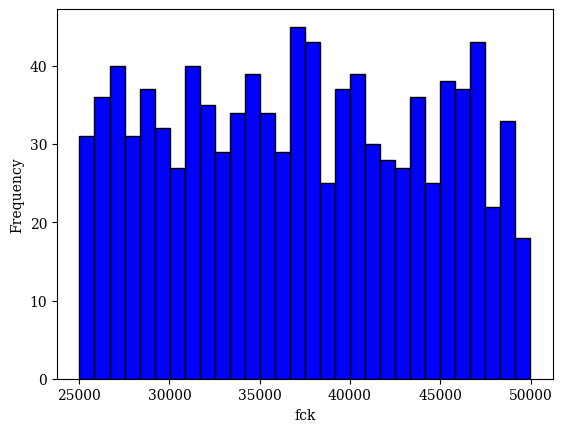

In [6]:
plt.hist(x[:, 1], bins=30, color='blue', edgecolor='black')
plt.xlabel('fck')
plt.ylabel('Frequency')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

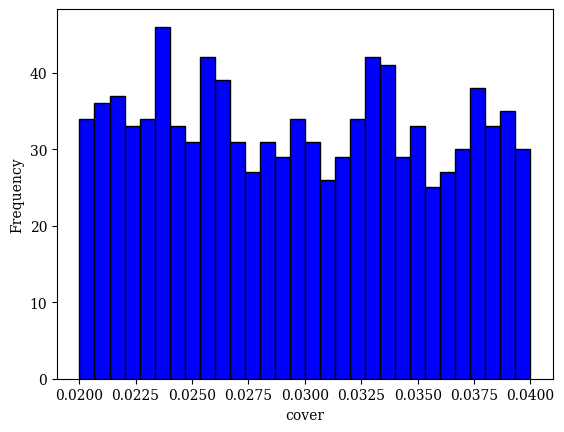

In [7]:
plt.hist(x[:, 0], bins=30, color='blue', edgecolor='black')
plt.xlabel('cover')
plt.ylabel('Frequency')
plt.show

### Determination of corrosion initiation time

In [44]:
# Compute corrosion initiation time
#tempo_iniciacao = np.inf
lifetime = 100
profile = beam_test.carbonation_profile(model=model, lifetime=lifetime)
cover = beam_test.geo['cover [m]'] * 1e3  # Convert to mm
start_year = beam_test.expo['Installation year']

for t in range(0, lifetime + 1):
    calendar_years = start_year + t
    carb_depth = beam_test.carbonation_depth_at_time(profile=profile, t_query=calendar_years)
    print(f"t={t:3d} anos | carb_depth = {carb_depth}")

    if carb_depth >= cover:
        tempo_iniciacao = t
        break

tempo_iniciacao

t=  0 anos | carb_depth = 0.19541493206813076
t=  1 anos | carb_depth = 1.703449071621884
t=  2 anos | carb_depth = 3.216830471222997
t=  3 anos | carb_depth = 4.730211870824114
t=  4 anos | carb_depth = 5.763453394550031
t=  5 anos | carb_depth = 6.339307852042831
t=  6 anos | carb_depth = 6.8366173460977455
t=  7 anos | carb_depth = 7.334803839294775
t=  8 anos | carb_depth = 7.901176471440874
t=  9 anos | carb_depth = 8.522425583468422
t= 10 anos | carb_depth = 9.146383143869503
t= 11 anos | carb_depth = 9.815238130924614
t= 12 anos | carb_depth = 10.484105172179522
t= 13 anos | carb_depth = 11.08505747672398
t= 14 anos | carb_depth = 11.416392801710051
t= 15 anos | carb_depth = 11.767427125381422
t= 16 anos | carb_depth = 12.13179136144407
t= 17 anos | carb_depth = 12.495146583775702
t= 18 anos | carb_depth = 12.858514707517307
t= 19 anos | carb_depth = 13.221895732668864
t= 20 anos | carb_depth = 13.58528965923041
t= 21 anos | carb_depth = 13.928386040229878
t= 22 anos | carb_dept

25

In [48]:
# Assign initiation time to beam
beam_test.tempo_iniciacao = tempo_iniciacao

### Limit state function evaluation

In [ ]:
# Reliability analysis
lambdas = []
gs = []

for t in lifetime:
    beam_t = beam.copy()
    beam_t['tempo_decorrido'] = t

    y, df = state_limit_function_time_real_beam(
        beams=[beam_t],
        n_latent_samples=n_latent_samples
    )

    lambdas.append(y[0])   # λ(t)
    gs.append(df[0])       # g(t)

In [ ]:
lambdas = np.vstack(lambdas)
lambdas

array([[ 34.13365488,   0.44269016,   0.08224917,   0.12274907],
       [ 34.26026772,   0.42223042,   0.10427187,   0.1616344 ],
       [ 34.12254856,   0.41204918,   0.13777824,   0.18518675],
       [ 14.5236142 ,   0.4589431 ,   0.07376366,   0.15959568],
       [  5.92280849,   0.42088346,   0.16708147,   0.2501177 ],
       [  0.95127531,   0.44705032,   0.0886276 ,   0.21913484],
       [ -3.05243126,   0.4837456 ,   0.05291493,   0.16705211],
       [ -6.31793219,   0.4691593 ,   0.10382573,   0.18987197],
       [ -9.23905365,   0.46619915,   0.10759513,   0.16558348],
       [-11.67230138,   0.49496136,   0.06348712,   0.14685541],
       [-14.04500944,   0.48254943,   0.07339389,   0.17693526]])

# Chart

### $g$ over the time

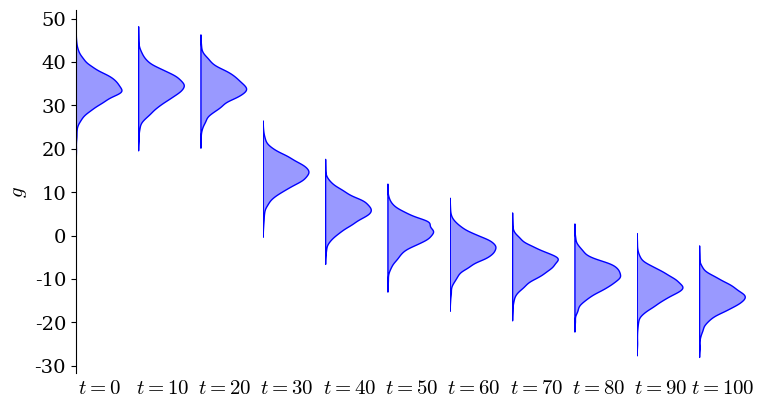

In [ ]:
### Figure name and DPI
dpi = 600
name = 'time-lapse_g_analysis'

### Chart dimensions
b_cm_individual = 2.0      
h_cm = 12                 
inches_to_cm = 1 / 2.54

n_plots = len(time) 
b_input_total = (b_cm_individual * n_plots) * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels
label_y = '$g$'
size_label = 15
color_label = 'black'
size_axis = 14
color_axis = 'black'
color = 'blue'
alpha = 0.4

### Figure
fig, axes = plt.subplots(nrows=1, ncols=n_plots, sharey=True, figsize=(b_input_total, h_input))

### Space between plots
plt.subplots_adjust(wspace=0.3) 

### Loop
for i, ax in enumerate(axes):
    
    ### Plot
    current_data = gs[i]
    sns.kdeplot(y=current_data['g'], fill=True, alpha=alpha, ax=ax, color=color)
    
    # Configurações gerais (Fonte, Cor)
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    
    # Label X
    ax.set_xlabel(f'$t={int(time[i])}$', fontsize=size_label, color=color_label)
    
    # Remove ticks e números do eixo X (como você pediu antes)
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # Remove bordas padrão (Topo, Direita, Baixo)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # --- AQUI ESTÁ A MÁGICA PARA REMOVER O EIXO Y DOS OUTROS ---
    if i == 0:
        # Primeiro gráfico: Mantém a linha da esquerda e o Label Y
        ax.spines['left'].set_visible(True)
        ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
    else:
        # Do segundo em diante:
        ax.spines['left'].set_visible(False)   # Remove a linha vertical
        ax.tick_params(axis='y', left=False)   # Remove os tracinhos (ticks) da esquerda
        ax.set_ylabel('')                      # Remove o label
        
### Save and Show
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

### $\lambda$ over the time

In [ ]:
y1 = lambdas[:,0]
y2 = lambdas[:,1]
y3 = lambdas[:,2]
y4 = lambdas[:,3]
data = [
        {'x': time, 'y': y1},
        {'x': time, 'y': y2},
        {'x': time, 'y': y3},
        {'x': time, 'y': y4}
    ]

### English version

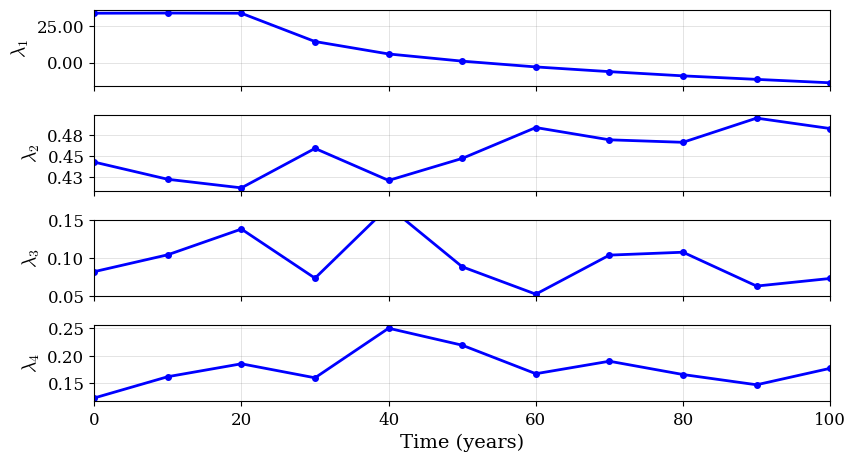

In [ ]:
import matplotlib.ticker as ticker
### Figure name and DPI
dpi = 600
name = 'lambdas_for_r_s_realization'

### Axis and labels
label_x = 'Time (years)'  
size_label = 14
color_label = 'black'
size_axis = 12
color_axis = 'black'

### Line
size_line = 2
style_line = '-'
color_line = 'blue'

### Marker
marker = 'o'
size_marker = 4
color_marker = 'blue'
color_marker_edge = color_line

### Legend
labels_legend = ['$\lambda _1$', '$\lambda _2$', '$\lambda _3$', '$\lambda _4$']  # Change as you wish
size_legend = 10
location_legend = 'upper right'

### Grid
on_or_off = True
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

### Figure
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(b_input_total, h_input))

### Plot
i = 0
for ax, dataset in zip(axes, data):
    
    ax.plot(dataset['x'], dataset['y'],
            markerfacecolor=color_marker, marker=marker, markersize=size_marker,
            linewidth=size_line, linestyle=style_line, color=color_line)
    
    # Configuração dos Eixos (Cores e Tamanhos)
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    
    # Label Y (Específico de cada gráfico, mas com seu estilo)
    ax.set_ylabel(labels_legend[i], fontsize=size_label, color=color_label)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    i += 1
    
    # Configuração do Grid
    ax.grid(on_or_off, which='both', linestyle=style_grid, linewidth=line_width_grid, color=color_grid, alpha=alpha_grid)
    
    # # Legenda
    # ax.legend(fontsize=size_legend, loc=location_legend)

# Ajuste específico para a Tangente (índice 2) pois ela vai ao infinito
axes[2].set_ylim(0.05, 0.15)

# Label X apenas no último gráfico
axes[-1].set_xlim(min(time), max(time))
axes[-1].set_xlabel(label_x, fontsize=size_label, color=color_label)

# Ajustar espaçamento
plt.tight_layout()

# --- 6. SALVAR E MOSTRAR ---
fig.savefig(f'z_{name}_en.png', dpi=dpi, bbox_inches='tight')
plt.show()

### Portuguese version

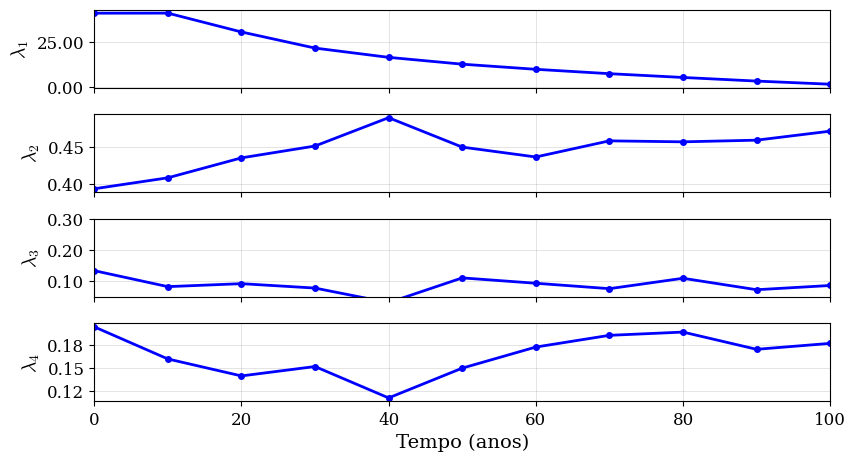

In [ ]:
import matplotlib.ticker as ticker
### Figure name and DPI
dpi = 600
name = 'lambdas_for_r_s_realization'

### Axis and labels
label_x = 'Tempo (anos)'  
size_label = 14
color_label = 'black'
size_axis = 12
color_axis = 'black'

### Line
size_line = 2
style_line = '-'
color_line = 'blue'

### Marker
marker = 'o'
size_marker = 4
color_marker = 'blue'
color_marker_edge = color_line

### Legend
labels_legend = ['$\lambda _1$', '$\lambda _2$', '$\lambda _3$', '$\lambda _4$']  # Change as you wish
size_legend = 10
location_legend = 'upper right'

### Grid
on_or_off = True
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

### Figure
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(b_input_total, h_input))

### Plot
i = 0
for ax, dataset in zip(axes, data):
    
    ax.plot(dataset['x'], dataset['y'],
            markerfacecolor=color_marker, marker=marker, markersize=size_marker,
            linewidth=size_line, linestyle=style_line, color=color_line)
    
    # Configuração dos Eixos (Cores e Tamanhos)
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    
    # Label Y (Específico de cada gráfico, mas com seu estilo)
    ax.set_ylabel(labels_legend[i], fontsize=size_label, color=color_label)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    i += 1
    
    # Configuração do Grid
    ax.grid(on_or_off, which='both', linestyle=style_grid, linewidth=line_width_grid, color=color_grid, alpha=alpha_grid)
    
    # # Legenda
    # ax.legend(fontsize=size_legend, loc=location_legend)

# Ajuste específico para a Tangente (índice 2) pois ela vai ao infinito
axes[2].set_ylim(0.05, 0.30)

# Label X apenas no último gráfico
axes[-1].set_xlim(min(time), max(time))
axes[-1].set_xlabel(label_x, fontsize=size_label, color=color_label)

# Ajustar espaçamento
plt.tight_layout()

# --- 6. SALVAR E MOSTRAR ---
fig.savefig(f'z_{name}_pt.png', dpi=dpi, bbox_inches='tight')
plt.show()